In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Required to import shared functions
import sys
sys.path.append('../src/')

#Required to save figures
import os

In [2]:
#Importing shared .py file containing shared functions
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [3]:
#Initializing cosmological parameters
from utils import h, Om_m, Om_b, Om_lambda, rho_c, z_range

In [4]:
#Unit Conversions

### Area Values

Mb_to_cm2 = 10 ** (-18)

### Mass

g_to_SM = 5.03 * 10 ** (-34)

### Distance

cm_to_Mpc = 3.24 * 10 ** (-25)
Mpc_to_km = 3.086 * 10 ** (19)
Mpc_to_cm = 3.086 * 10 ** (24)

### Time

yr_to_s = 3.154 * 10 ** 7

###

Erg_to_keV = 6.242 * 10 ** 8

# Full $\sigma(E,z)$ Calculation

Cross-sections defined as given by fitting formula Verner et al. 1996:

$$\sigma(E)=\sigma_0F(y)\text{ Mb}\text{, }x=\frac{E}{E_0}-y_0\text{, }y=\sqrt{x^2+y_1^2}$$

$$F(y)=\left[(x-1)^2+y_w^2\right]y^{0.5P-5.5}\left(1+\sqrt{\frac{y}{y_a}}\right)^{-P}$$

where $E_0$, $\sigma_0$, $y_a$, $P$, $y_w$, $y_0$, and $y_1$ are fitting parameters.

In [5]:
#Defining functions according to above mentioned fitting-formula

def x_FullSigma(E, E_0, y_0):
    return E / E_0 - y_0

def y_FullSigma(E, E_0, y_0, y_1):
    return np.sqrt(x_FullSigma(E, E_0, y_0) ** 2 + y_1 ** 2)

def F_FullSigma(E, E_0, y_0, y_1, y_w, P, y_a):
    return ((x_FullSigma(E, E_0, y_0) - 1) ** 2 + y_w ** 2) * y_FullSigma(E, E_0, y_0, y_1) ** (0.5 * P - 5.5) * (1 + np.sqrt(y_FullSigma(E, E_0, y_0, y_1) / y_a)) ** (-P)

def sigma_FullSigma(E, E_0, y_0, y_1, y_w, P, y_a, sigma_0):
    return sigma_0 * F_FullSigma(E, E_0, y_0, y_1, y_w, P, y_a)

In [6]:
E_val = 1 #keV

#For H_I:
E_0_HI = 0.4298 * 10 ** (-3) #in keV
y_0_HI = 0
y_1_HI = 0
y_w_HI = 0
P_HI = 2.963
y_a_HI = 32.88
sigma_0_HI = 5.475 * 10 ** (4) * Mb_to_cm2 #in cm^2

#For He_I:
E_0_HeI = 13.61 * 10 ** (-3) #in keV
y_0_HeI = 0.4434
y_1_HeI = 2.136
y_w_HeI = 2.039
P_HeI = 3.188
y_a_HeI = 1.469
sigma_0_HeI = 9.492 * 10 ** (2) * Mb_to_cm2 #in cm^2

#For He_II:
E_0_HeII = 1.720 * 10 ** (-3) #in keV
y_0_HeII = 0
y_1_HeII = 0
y_w_HeII = 0
P_HeII = 2.963
y_a_HeII = 32.88
sigma_0_HeII = 1.369 * 10 ** (4) * Mb_to_cm2 #in cm^2

In [7]:
#Test values at E=1 keV
sigma_HI_FullSigma = sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
sigma_HeI_FullSigma = sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)
sigma_HeII_FullSigma = sigma_FullSigma(E_val, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)

In [8]:
#Effective cross section in energy range E=0.1-3 keV as given by Madau and Fragos 2017

abund_He = 0.083

eff_neutralSigma = sigma_HI_FullSigma + abund_He * sigma_HeI_FullSigma #in cm^2

eff_neutralSigma

np.float64(3.921429969667205e-23)

# Fully Neutral IGM

## 0.1-3 keV $\lambda_\text{X}$ Approximation

Madau and Fragos 2017 specifies that within the 0.1-3 keV energy ranges, the effective scattering cross-section can be approximated as:

$$\sigma=(3.9\times10^{-23}\text{ cm}^2)\left(\frac{E}{\text{keV}}\right)^{-3.2}$$

to within 18% accuracy.

In [9]:
m_p = 1.6726219e-24     # g

In [10]:
from numba import jit
from utils import H

In [11]:
@jit(nopython=True)
def MFP_X(E,z): #Mean Free Path, proper coordinates, Mpc. Energy in keV
    X = 0.75 #fraction of hydrogen by mass
    m_p_SM = m_p * g_to_SM #mass of proton in SM
    eff_neutralSigma_Mpc = eff_neutralSigma * (cm_to_Mpc) ** 2 #Neutral cross section in Mpc^2
    prefac = m_p_SM / (Om_b * rho_c * eff_neutralSigma_Mpc * X * 1000)
    return prefac * E ** (3.2) * ((1 + z) / 10) ** (-3)

@jit(nopython=True)
def Tau_X_integrand(E_prime, z_b, z_p): #Dummy variable of integration
    c_val = (3 * 10 ** 5) * yr_to_s #speed of light in km/yr
    E = E_prime * (1 + z_b) / (1 + z_p)
    return c_val / ((1 + z_b) * (H(z_b) * Mpc_to_km) * MFP_X(E, z_b)) #H(z) in km/yr*Mpc

@jit(nopython=True)
def Tau_X(E_p, z_p, z, delta_z): #X-ray Optical Depth, proper coordinates at some emission redshift z_p and energy E_p, observed at z
    c_val = (3 * 10 ** 5) * yr_to_s #speed of light in km/yr
    integration_steps = int((z_p - z) / delta_z)
    z_arr = np.linspace(z, z_p, integration_steps)
    integrand_vals = np.zeros_like(z_arr)
    for i in range(len(z_arr)):
        integrand_vals[i] = Tau_X_integrand(E_p, z_arr[i], z_p)
    return np.trapz(integrand_vals, z_arr)

In [12]:
MFP_test_arr = MFP_X(1, z_range)

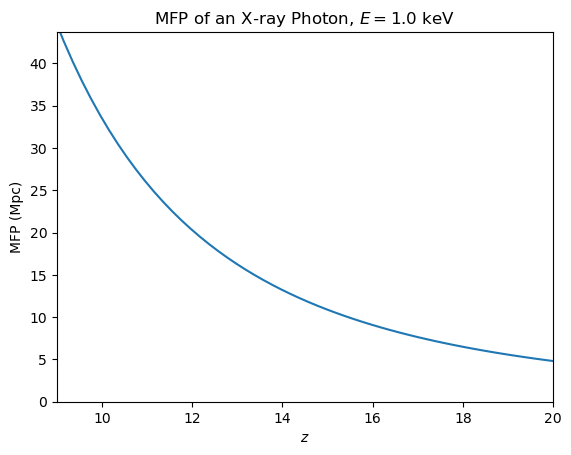

In [13]:
plt.plot(z_range, MFP_test_arr)
plt.xlabel(r'$z$')
plt.ylabel(r'MFP (Mpc)')
plt.xlim(9, 20)
plt.ylim(0, 43.7)
plt.title(r'MFP of an X-ray Photon, $E=1.0$ keV')

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "TestMPF_z.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [107]:
"""

#Checking MFP Calculation

MFP_check = 43.7 * ((1 + 9) / 10) ** (-3) #According to approximation formula

print(MFP_check, MFP_X(1, 9))

"""

'\n\n#Checking MFP Calculation\n\nMFP_check = 43.7 * ((1 + 9) / 10) ** (-3) #According to approximation formula\n\nprint(MFP_check, MFP_X(1, 9))\n\n'

In [14]:
#Generating optical depth test data as a function of redshift

Tau_test_arr = np.zeros_like(z_range)

z_obs_test = 8

for i in range(len(z_range)):
    if z_range[i] > z_obs_test:
        Tau_test_arr[i] = Tau_X(1, z_range[i], z_obs_test, 0.0001)

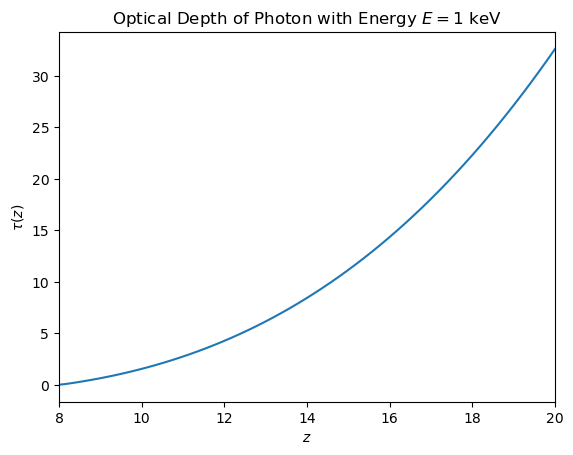

In [15]:
plt.plot(z_range, Tau_test_arr)
plt.xlabel(r'$z$')
plt.ylabel(r'$\tau(z)$')
plt.title(r'Optical Depth of Photon with Energy $E=1$ keV')

plt.xlim(8, 20)

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "TestOpticalDepth_z.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""
plt.show()

In [110]:
"""

#Checking Optical Depth Calculation

c_val = 3 * 10 ** 5 #km/s

Tau_Check = c_val / (67 * np.sqrt(Om_m)) * (43.7 * 1000 * (1 / (1 + 15)) ** (3.2)) ** (-1) * ((1 + 8) ** (-1.7) / 1.7 - (1 + 15) ** (-1.7) / (1.7))

print(Tau_Check, Tau_X(1, 15, 8, 0.0001))


"""

'\n\n#Checking Optical Depth Calculation\n\nc_val = 3 * 10 ** 5 #km/s\n\nTau_Check = c_val / (67 * np.sqrt(Om_m)) * (43.7 * 1000 * (1 / (1 + 15)) ** (3.2)) ** (-1) * ((1 + 8) ** (-1.7) / 1.7 - (1 + 15) ** (-1.7) / (1.7))\n\nprint(Tau_Check, Tau_X(1, 15, 8, 0.0001))\n\n\n'

In [16]:
#Energy band used throughout the code

E_range = np.logspace(np.log10(0.5), np.log10(8)) #in keV

In [17]:
#Energy dependence of the optical depth

Tau_test_arr2 = np.zeros_like(E_range)

z_obs_test = 7

for i in range(len(E_range)):
    Tau_test_arr2[i] = Tau_X(E_range[i], 10, z_obs_test, 0.0001)

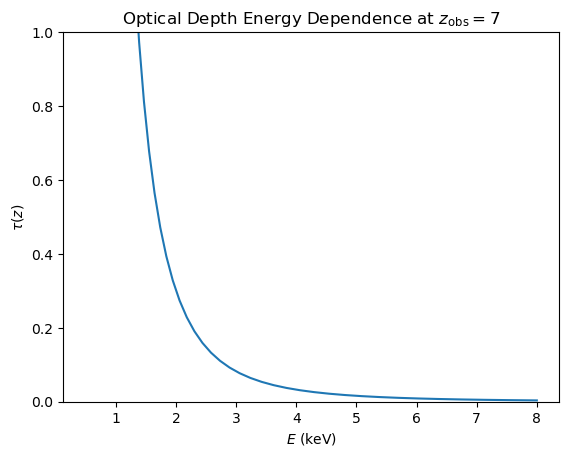

In [18]:
plt.plot(E_range, Tau_test_arr2)
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'$\tau(z)$')
plt.ylim(0,1)
plt.title(r'Optical Depth Energy Dependence at $z_\text{obs}=7$')

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "TestOpticalDepth_E.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [19]:
from utils import mean_cx_scat, Hopkin_SFRD

In [20]:
cX_vals = np.mean(mean_cx_scat) #In erg/s * yr/SM, cX = L_x/SFR

#Radiation intensity integrand

def J_E_integrand(E_obs, z_obs, z_prime):

    gamma_index = 2 #photon/spectral index
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs) #Emission energy

    return Hopkin_SFRD(z_prime) * cX_vals * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * Mpc_to_km / (yr_to_s))
    ) * np.exp(-Tau_X(E_prime, z_prime, z_obs, 0.001))

#Radiation intensity integral

def J(E, z): #Input observed energy and observation redshift

    gamma_index = 2 #Photon/spectral index
    c_kms = 3e5 #speed of light in km/s

    z_start = z #Observation redshift
    z_end = z + 4 #Emission redshift
    n_steps = 1000 #integration steps

    dz = (z_end - z_start) / (n_steps - 1) #integration step length

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0 #Integral value tracker at each step

    #Initializing initial conditions
    
    z_prev = z_start
    f_prev = J_E_integrand(E, z, z_prev)

    #Integration step

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand(E, z, z_curr) #Integrand value at current step

        integral += 0.5 * (f_prev + f_curr) * dz #Adding current step contribution to integral value tracker

        #Resetting previous step values

        z_prev = z_curr
        f_prev = f_curr

    #Final integral value

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [21]:
#Generating the J_E spectrum in erg/s/Mpc^2/sr/keV

J_test_vals2 = np.zeros_like(E_range)
J_test_vals3 = np.zeros_like(E_range)
J_test_vals4 = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_vals2[i] = J(E_range[i], 9)
    J_test_vals3[i] = J(E_range[i], 11)
    J_test_vals4[i] = J(E_range[i], 13)

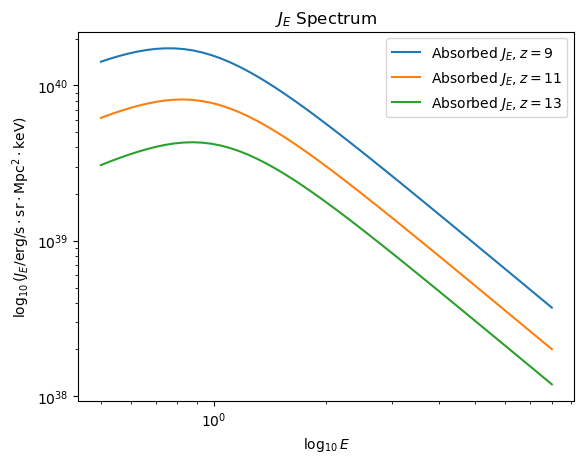

In [22]:
plt.loglog(E_range, J_test_vals2, label = r'Absorbed $J_E, z=9$')
#
plt.loglog(E_range, J_test_vals3, label = r'Absorbed $J_E, z=11$')
plt.loglog(E_range, J_test_vals4, label = r'Absorbed $J_E, z=13$')
plt.xlabel(r'$\log_{10}{E}$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "JE_erg_Mpc2.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [23]:
#Converting to units of Madau paper (keV/s/cm^2/sr/keV)

J_test_vals_2_New = J_test_vals2 * Erg_to_keV / (Mpc_to_cm) ** 2
J_test_vals_3_New = J_test_vals3 * Erg_to_keV / (Mpc_to_cm) ** 2
J_test_vals_4_New = J_test_vals4 * Erg_to_keV / (Mpc_to_cm) ** 2

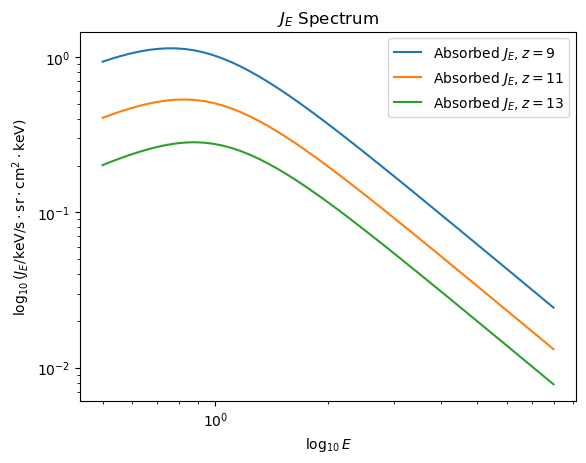

In [24]:
plt.loglog(E_range, J_test_vals_2_New , label = r'Absorbed $J_E, z=9$')
#
plt.loglog(E_range, J_test_vals_3_New , label = r'Absorbed $J_E, z=11$')
plt.loglog(E_range, J_test_vals_4_New , label = r'Absorbed $J_E, z=13$')
plt.xlabel(r'$\log_{10}{E}$')
plt.ylabel(r'$\log_{10}{(J_E/\text{keV/s}\cdot\text{sr}\cdot\text{cm}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "JE_keV_cm2.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [36]:
"""

#Testing J_E value

c_val = 3e5 #in km/s

J_E_test_value = c_val / (4 * np.pi) * 10 ** 5 * 10 ** (-3) * 10 ** (39.4) / (67 * np.sqrt(0.315)) * 8 / 15 * 10 ** (-7 / 2) * 2 / 7

#Test J_E function according to our approximations:

def J_E_test_integrand(E_obs, z_obs, z_prime):

    gamma_index = 2 #photon/spectral index
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs) #Emission energy

    return 10 ** (-3) * 10 ** (39.4) * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * Mpc_to_km / (yr_to_s))
    ) * 1

#Radiation intensity integral

def J_test(E, z): #Input observed energy and observation redshift

    gamma_index = 2 #Photon/spectral index
    c_kms = 3e5 #speed of light in km/s

    z_start = z #Observation redshift
    z_end = z + 4 #Emission redshift
    n_steps = 1000 #integration steps

    dz = (z_end - z_start) / (n_steps - 1) #integration step length

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0 #Integral value tracker at each step

    #Initializing initial conditions
    
    z_prev = z_start
    f_prev = J_E_test_integrand(E, z, z_prev)

    #Integration step

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_test_integrand(E, z, z_curr) #Integrand value at current step

        integral += 0.5 * (f_prev + f_curr) * dz #Adding current step contribution to integral value tracker

        #Resetting previous step values

        z_prev = z_curr
        f_prev = f_curr

    #Final integral value

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

J_func_test_val = J_test(1, 9)

print(J_E_test_value, J_func_test_val)

"""

'\n\n#Testing J_E value\n\nc_val = 3e5 #in km/s\n\nJ_E_test_value = c_val / (4 * np.pi) * 10 ** 5 * 10 ** (-3) * 10 ** (39.4) / (67 * np.sqrt(0.315)) * 8 / 15 * 10 ** (-7 / 2) * 2 / 7\n\n#Test J_E function according to our approximations:\n\ndef J_E_test_integrand(E_obs, z_obs, z_prime):\n\n    gamma_index = 2 #photon/spectral index\n    E_prime = E_obs * (1 + z_prime) / (1 + z_obs) #Emission energy\n\n    return 10 ** (-3) * 10 ** (39.4) * (1 + z_prime) ** -gamma_index / (\n        (1 + z_prime) * (H(z_prime) * Mpc_to_km / (yr_to_s))\n    ) * 1\n\n#Radiation intensity integral\n\ndef J_test(E, z): #Input observed energy and observation redshift\n\n    gamma_index = 2 #Photon/spectral index\n    c_kms = 3e5 #speed of light in km/s\n\n    z_start = z #Observation redshift\n    z_end = z + 4 #Emission redshift\n    n_steps = 1000 #integration steps\n\n    dz = (z_end - z_start) / (n_steps - 1) #integration step length\n\n    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - 

## Metallicity-Redshift Relation

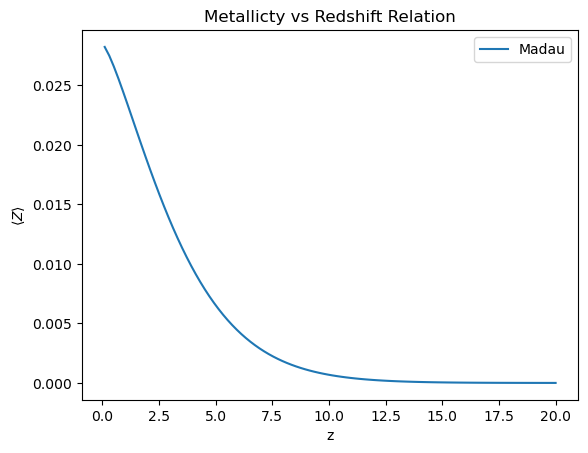

In [52]:
Z_solar = 0.02 #Solar Metallicity
Mean_Z = Z_solar * 10 ** (0.153 - 0.074 * z_range ** 1.34) #Mean metallicity fitting function as fiven by Madau 2017

plt.plot(z_range, Mean_Z, label = r'Madau')
plt.xlabel(r'z')

plt.ylabel(r'$\left<Z\right>$')
plt.legend()

plt.title(r'Metallicty vs Redshift Relation')

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "Z_z_reln.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

## Luminosity-Metallicity Relation

In [53]:
def log_cX_Mad(mean_Z): #cX-Metallicity fitting function given by Madau 2017
    return 40.431737 + 135.11736 * mean_Z + -106273.6 * mean_Z ** 2 + 25606802 * mean_Z ** 3 - (3.0811049 * 10 ** 9) * mean_Z ** 4 + (2.0496541 * 10 ** (11)) * mean_Z ** 5 - (7.6798616 * 10 ** (12)) * mean_Z ** 6 + (1.5199552 * 10 ** (14)) * mean_Z ** 7 - (1.2367941 * 10 ** (15)) * mean_Z ** 8

In [40]:
log_cX_Mad_vals = np.zeros_like(Mean_Z)

for i in range(len(Mean_Z)):
    log_cX_Mad_vals[i] = log_cX_Mad(Mean_Z[i])

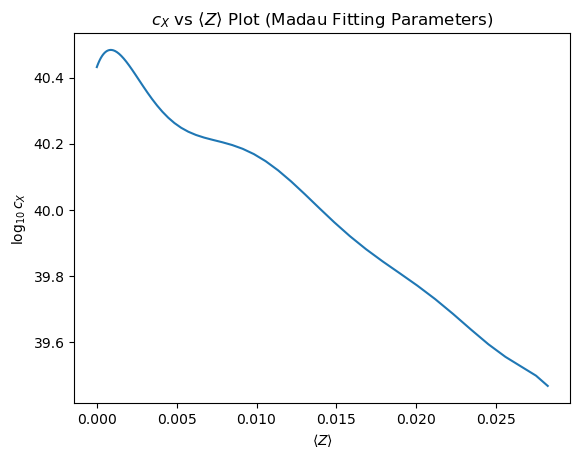

In [49]:
plt.plot(Mean_Z, log_cX_Mad_vals)
plt.xlabel(r'$\left<Z\right>$')
plt.ylabel(r'$\log_{10}c_X$')
plt.title(r'$c_X$ vs $\left<Z\right>$ Plot (Madau Fitting Parameters)')

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "cX_Z_rel.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

## Luminosity-Redshift Relation

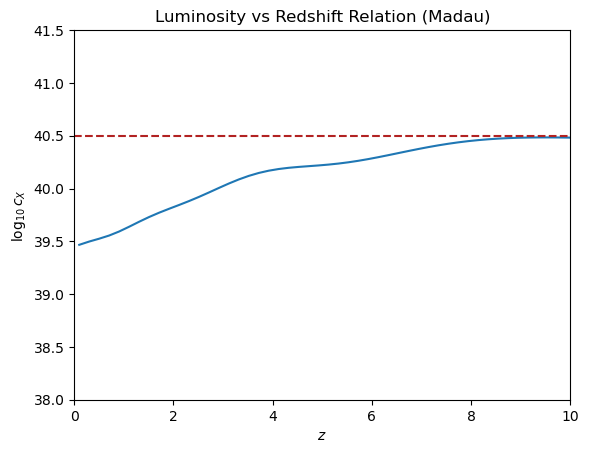

In [51]:
plt.plot(z_range, log_cX_Mad_vals)
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}c_X$')
plt.title(r'Luminosity vs Redshift Relation (Madau)')
plt.ylim(38, 41.5)
plt.xlim(0,10)
plt.axhline(40.5, ls = '--', color = r'firebrick')

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "cX_z_reln.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")


"""

plt.show()

## Madau Normalization for $J_E$

In [54]:
cX_new_vals = 10 ** log_cX_Mad_vals #In erg/s * yr/SM, cX = L_x/SFR

from scipy.interpolate import interp1d

#Interpolating the cX array:

cX_func = interp1d(z_range, cX_new_vals, kind = "linear")

#Radiation intensity integrand

def J_E_new_integrand(E_obs, z_obs, z_prime):

    gamma_index = 2 #photon/spectral index
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs) #Emission energy

    return Hopkin_SFRD(z_prime) * cX_func(z_prime) * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * Mpc_to_km / (yr_to_s))
    ) * np.exp(-Tau_X(E_prime, z_prime, z_obs, 0.001))

#Radiation intensity integral

def J_new(E, z): #Input observed energy and observation redshift

    gamma_index = 2 #Photon/spectral index
    c_kms = 3e5 #speed of light in km/s

    z_start = z #Observation redshift
    z_end = z + 4 #Emission redshift
    n_steps = 1000 #integration steps

    dz = (z_end - z_start) / (n_steps - 1) #integration step length

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0 #Integral value tracker at each step

    #Initializing initial conditions
    
    z_prev = z_start
    f_prev = J_E_new_integrand(E, z, z_prev)

    #Integration step

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_new_integrand(E, z, z_curr) #Integrand value at current step

        integral += 0.5 * (f_prev + f_curr) * dz #Adding current step contribution to integral value tracker

        #Resetting previous step values

        z_prev = z_curr
        f_prev = f_curr

    #Final integral value

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [55]:
#Generating the J_E spectrum in erg/s/Mpc^2/sr/keV

J_new_test_vals1 = np.zeros_like(E_range)
J_new_test_vals2 = np.zeros_like(E_range)
J_new_test_vals3 = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_new_test_vals1[i] = J_new(E_range[i], 9)
    J_new_test_vals2[i] = J_new(E_range[i], 11)
    J_new_test_vals3[i] = J_new(E_range[i], 13)

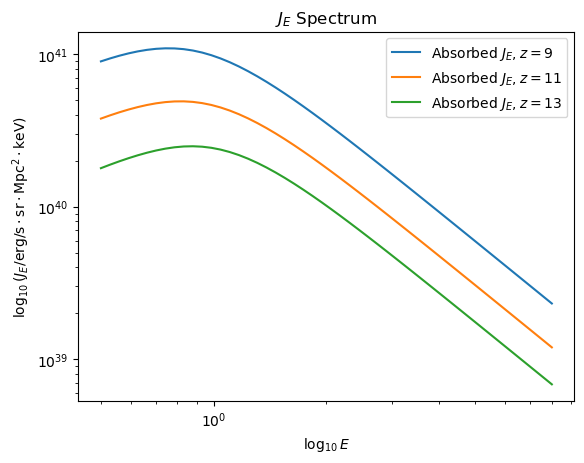

In [57]:
plt.loglog(E_range, J_new_test_vals1, label = r'Absorbed $J_E, z=9$')
#
plt.loglog(E_range, J_new_test_vals2, label = r'Absorbed $J_E, z=11$')
plt.loglog(E_range, J_new_test_vals3, label = r'Absorbed $J_E, z=13$')
plt.xlabel(r'$\log_{10}{E}$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "JE_new_erg_Mpc2.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [58]:
#Converting to units of Madau paper (keV/s/cm^2/sr/keV)

J_new_test_vals_1_New = J_new_test_vals1 * Erg_to_keV / (Mpc_to_cm) ** 2
J_new_test_vals_2_New = J_new_test_vals2 * Erg_to_keV / (Mpc_to_cm) ** 2
J_new_test_vals_3_New = J_new_test_vals3 * Erg_to_keV / (Mpc_to_cm) ** 2

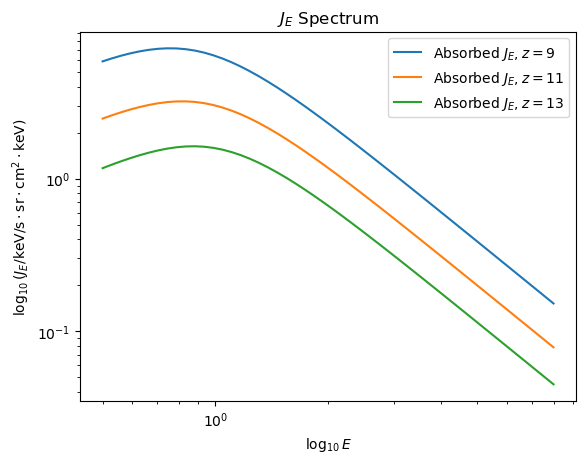

In [60]:
plt.loglog(E_range, J_new_test_vals_1_New, label = r'Absorbed $J_E, z=9$')
#
plt.loglog(E_range, J_new_test_vals_2_New, label = r'Absorbed $J_E, z=11$')
plt.loglog(E_range, J_new_test_vals_3_New, label = r'Absorbed $J_E, z=13$')
plt.xlabel(r'$\log_{10}{E}$')
plt.ylabel(r'$\log_{10}{(J_E/\text{keV/s}\cdot\text{sr}\cdot\text{cm}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "JE_new_keV_cm2.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

# $J_E$ Calculation for Madau Emissivity

## Emissivity Relations

In [125]:
def Madau_SFRD(z):
    return 0.01 * (1 + z) ** 2.6 / (1 + ((1 + z) / 3.2) ** 6.2)

Madau_fit = Madau_SFRD(z_range)

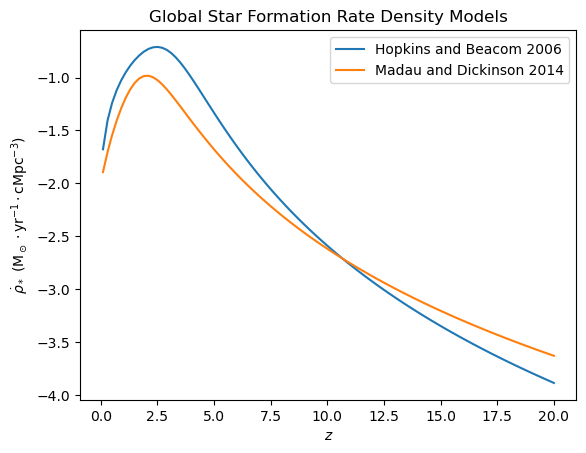

In [126]:
plt.plot(z_range, np.log10(Hopkin_SFRD(z_range)), label = r'Hopkins and Beacom 2006')
plt.plot(z_range, np.log10(Madau_SFRD(z_range)), label = r'Madau and Dickinson 2014')
plt.xlabel(r'$z$')
plt.ylabel(r'$\dot{\rho}_*$ (M$_\odot\cdot$yr$^{-1}\cdot$cMpc$^{-3}$)')
plt.title(r'Global Star Formation Rate Density Models')
plt.legend()

"""

# Folder where you want to save the figure
save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "SFRD_Models.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [127]:
def Metallicity_reln(z):
    return Z_solar * 10 ** (0.153 - 0.074 * z ** 1.34)

def log_Mad_Em(z):
    Metallicity = Metallicity_reln(z)
    SFRD_val = Madau_SFRD(z)
    logcX_val = log_cX_Mad(Metallicity)
    return np.log10(SFRD_val) + logcX_val

log_Mad_Em_vals = log_Mad_Em(z_range)

Text(0, 0.5, '$\\log_{10}\\epsilon_\\text{HMXB}$')

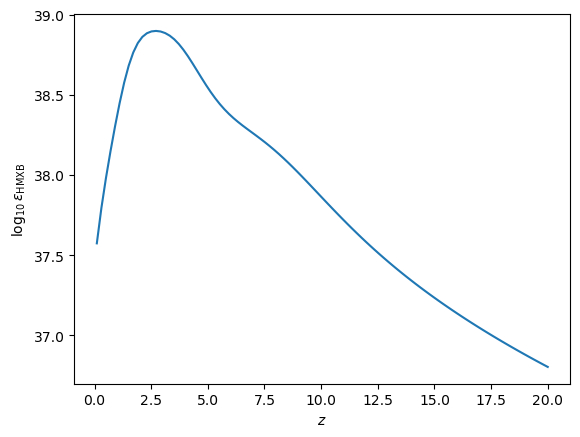

In [128]:
plt.plot(z_range, log_Mad_Em_vals)
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}\epsilon_\text{HMXB}$')

In [129]:
E_times_Em = np.zeros_like(E_range)

for i in range(len(E_range)):
    E_times_Em[i] = E_range[i] * 10 ** log_Mad_Em(7) * E_range[i] ** (-2)

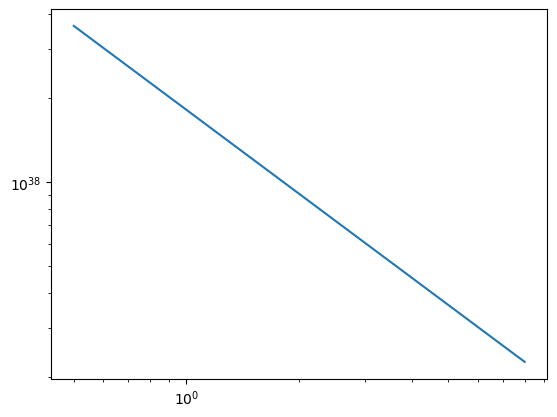

In [130]:
plt.loglog(E_range, E_times_Em)

In [131]:
def J_E_integrand_Mad(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return 10 ** (log_Mad_Em(z_prime)) * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) / (3.24e-20))
    ) * np.exp(-Tau_X(E_prime, z_prime, z_obs, 0.001))

def J_Mad(E, z):

    gamma_index = 2
    c_kms = 3e5 * 3.17 * 10 ** 8

    z_start = z
    z_end = z + 4
    n_steps = 1000

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_Mad(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_Mad(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [132]:
def J2_Mad(E, z):

    gamma_index = 1.5
    c_kms = 3e5 * 3.17 * 10 ** 8

    z_start = z
    z_end = z + 4
    n_steps = 1000

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_Mad(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_Mad(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

def J3_Mad(E, z):

    gamma_index = 2.5
    c_kms = 3e5 * 3.17 * 10 ** 8

    z_start = z
    z_end = z + 4
    n_steps = 1000

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_Mad(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_Mad(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [133]:
J_test_valsMad = np.zeros_like(E_range) #J_E spectrum
J_test_valsMad2 = np.zeros_like(E_range)
J_test_valsMad3 = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_valsMad[i] = J(E_range[i], 8)
    J_test_valsMad2[i] = J2(E_range[i], 8)
    J_test_valsMad3[i] = J3(E_range[i], 8)

NameError: name 'J2' is not defined

In [ ]:
plt.loglog(E_range, (J_test_valsMad), label = r'Absorbed $J_E,z=8$')
#plt.loglog(E_range, (J_test_valsMad2), label = r'Absorbed $J_E,z=10$')
#plt.loglog(E_range, (J_test_valsMad3), label = r'Absorbed $J_E,z=12$')
plt.xlabel(r'$\log_{10}E$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum at $z_{\text{obs}}=8$')
plt.legend()

#* 6.242 * 10 ** 8 / (3.086 * 10 ** 24) ** 2)

# Solving the Temeperature Differential Equation

## Photo-Heating Rates (Only HI)

Since this is just HI, we assume a simple $\sigma\propto E^{-3}$ relation here.

In [134]:
from scipy.integrate import quad, solve_ivp
from scipy.interpolate import interp1d

In [135]:
SIGMA_HI_0 = 6.3e-18  # cm^2
I_HI_KEV = 0.0136 #keV
I_HeI_KEV = 0.0246 #keV

def sigma_HI(E): # E in keV
    return SIGMA_HI_0 * (I_HI_KEV / E) ** 3

def H_HI(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_HI(E_val)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [136]:
def H_HI2(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J2(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_HI(E_val)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HI3(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J3(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_HI(E_val)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [137]:
z_grid = np.linspace(0, 15, 100)
H_HI_vals = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals[i] = H_HI(z_grid[i])

In [138]:
#H_HI_vals2 = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals2[i] = H_HI2(z_grid[i])

In [139]:
#H_HI_vals3 = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals3[i] = H_HI3(z_grid[i])

In [140]:
#H_HI_vals_Data = np.column_stack((H_HI_vals, H_HI_vals2, H_HI_vals3))

#np.savetxt("../Data/H_HI_ValsData.csv", H_HI_vals_Data, delimiter = ",", header = "H_HI_1, H_HI_2, H_HI3")

In [141]:
H_HI_vals, H_HI_vals2, H_HI_vals3 = np.genfromtxt("../Data/H_HI_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

Text(0.5, 1.0, 'Photoheating rate of HI as a function of $z$')

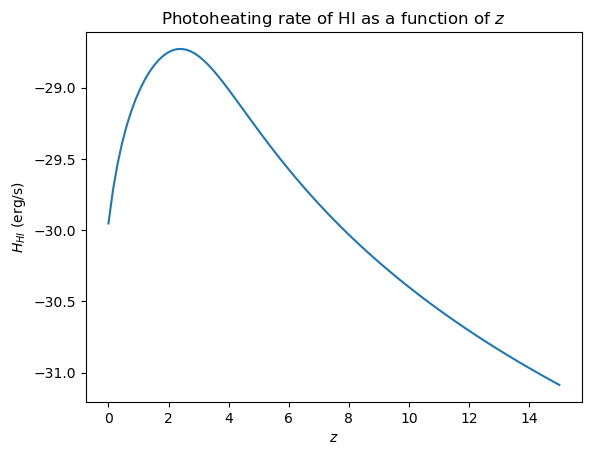

In [142]:
plt.plot(z_grid, np.log10(H_HI_vals))
#plt.plot(z_grid, np.log10(H_HI_vals2))
#plt.plot(z_grid, np.log10(H_HI_vals3))
plt.ylabel(r'$H_{HI}$ (erg/s)')
plt.xlabel(r'$z$')
plt.title(r'Photoheating rate of HI as a function of $z$')
#plt.axvline(8)

## Temperature Differential Equation (Only HI)

Since this is just HI, we assume a simple $\sigma\propto E^{-3}$ relation here.

In [146]:
mu = 1.23
k_B = 1.38 * 10 ** (-16) #erg/K
X_frac = 0.75

Yrtosec = 3.154 * 10 ** 7

H_0 = 67 #km/s/Mpc
MpctoKm = 3.086 * 10 ** 19

H_HI_interp = interp1d(
    z_grid[::-1],
    H_HI_vals[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS(z, T):
    T = T[0]
    HHI = H_HI_interp(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * X_frac / ((1 + z) * (H(z) / Yrtosec)) * HHI

def in_Temp(z):
    z_dec = 150
    return 2.725 * (1 + z) ** 2 / (z_dec + 1)

In [147]:
H_HI_interp2 = interp1d(
    z_grid[::-1],
    H_HI_vals2[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS2(z, T):
    T = T[0]
    HHI = H_HI_interp2(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * X_frac / ((1 + z) * (H(z) / Yrtosec)) * HHI

H_HI_interp3 = interp1d(
    z_grid[::-1],
    H_HI_vals3[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS3(z, T):
    T = T[0]
    HHI = H_HI_interp3(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * X_frac / ((1 + z) * (H(z) / Yrtosec)) * HHI

In [148]:
T_sol = solve_ivp(temp_RHS, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))

In [149]:
T_sol2 = solve_ivp(temp_RHS2, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))
T_sol3 = solve_ivp(temp_RHS3, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))

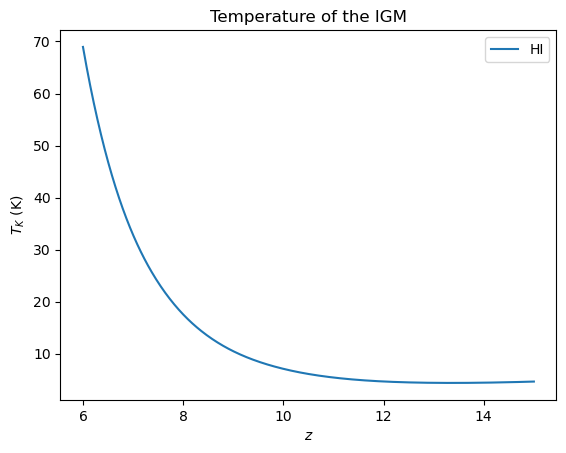

In [150]:
z_sol_grid = T_sol.t[::-1]
T_sol_vals = T_sol.y[0][::-1]

#z_sol_grid2 = T_sol2.t[::-1]
#T_sol_vals2 = T_sol2.y[0][::-1]

#z_sol_grid3 = T_sol3.t[::-1]
#T_sol_vals3 = T_sol3.y[0][::-1]

plt.plot(z_sol_grid, T_sol_vals, label = r'HI')
#plt.plot(z_sol_grid2, T_sol_vals2, label = r'Constant')
#plt.plot(z_sol_grid3, T_sol_vals3, label = r'Constant New')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_K$ (K)')
plt.title(r'Temperature of the IGM')
plt.legend()

## Photo-Heating Rates (Full Neutral IGM)

Here we take the $\sigma$ fitting relations found in Verner 1996.

In [151]:
def H_HI_FullSigma(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HeI_FullSigma(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HeI_KEV) * sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [152]:
H_HI_vals_FullSigma = np.zeros_like(z_grid)
H_HeI_vals_FullSigma = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals_FullSigma[i] = H_HI_FullSigma(z_grid[i])
#    H_HeI_vals_FullSigma[i] = H_HeI_FullSigma(z_grid[i])

In [153]:
#H_Neutral_vals_Data = np.column_stack((H_HI_vals_FullSigma, H_HeI_vals_FullSigma))

#np.savetxt("../Data/H_Neutral_ValsData.csv", H_Neutral_vals_Data, delimiter = ",", header = "H_HI, H_HeI")

In [154]:
H_HI_vals_FullSigma, H_HeI_vals_FullSigma = np.genfromtxt("../Data/H_Neutral_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

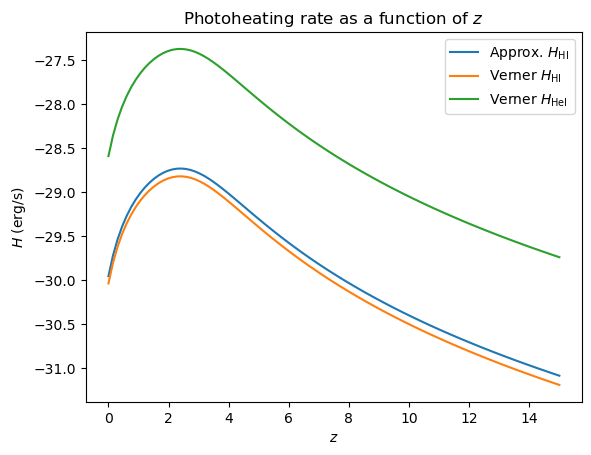

In [155]:
plt.plot(z_grid, np.log10(H_HI_vals), label = r'Approx. $H_\text{HI}$')
plt.plot(z_grid, np.log10(H_HI_vals_FullSigma), label = r'Verner $H_\text{HI}$')
plt.plot(z_grid, np.log10(H_HeI_vals_FullSigma), label = r'Verner $H_\text{HeI}$')
plt.ylabel(r'$H$ (erg/s)')
plt.xlabel(r'$z$')
plt.title(r'Photoheating rate as a function of $z$')
plt.legend()

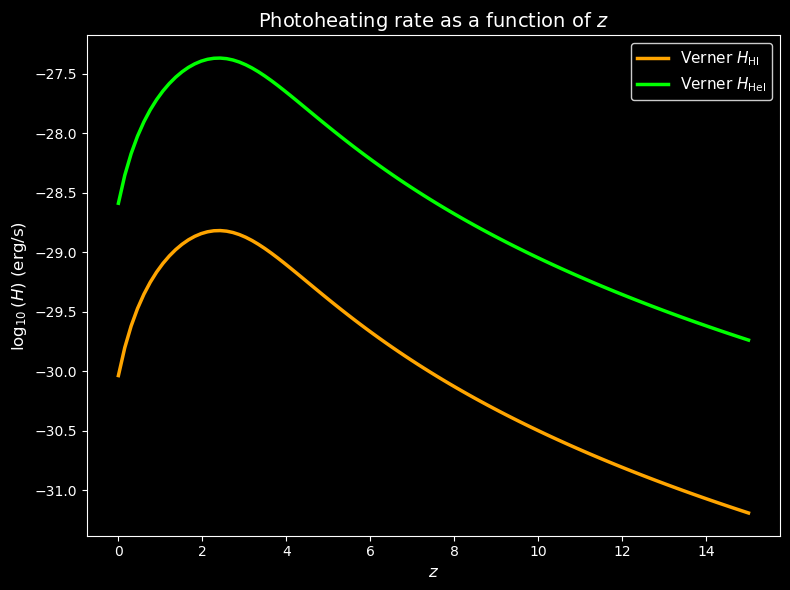

In [156]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
#ax.plot(z_grid, np.log10(H_HI_vals),
#        label=r'Approx. $H_\text{HI}$',
#        color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_grid, np.log10(H_HI_vals_FullSigma),
        label=r'Verner $H_\text{HI}$',
        color='#FFA500', lw=2.5)   # orange

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma),
        label=r'Verner $H_\text{HeI}$',
        color='#00FF00', lw=2.5)   # green

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(H)$ (erg/s)', fontsize=12, color='white')
ax.set_title(r'Photoheating rate as a function of $z$', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

## Temperature Differential Equation (Full Neutral IGM)

Here we take the $\sigma$ fitting relations found in Verner 1996.

In [157]:
Y_frac = 0.25
He_n_factor = Y_frac / 4

H_HI_interp_FullSigma = interp1d(
    z_grid[::-1],
    H_HI_vals_FullSigma[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

H_HeI_interp_FullSigma = interp1d(
    z_grid[::-1],
    H_HeI_vals_FullSigma[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS_FullSigma(z, T):
    T = T[0]
    HHI = H_HI_interp_FullSigma(z)
    HHeI = H_HeI_interp_FullSigma(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * (X_frac * HHI + He_n_factor * HHeI) / ((1 + z) * (H(z) / Yrtosec))

In [158]:
T_sol_FullSigma = solve_ivp(temp_RHS_FullSigma, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))

In [159]:
def adiabatic_temperature(z_array, T_init):
    z0 = z_array[0]
    return T_init * ((1 + z_array) / (1 + z0))**2

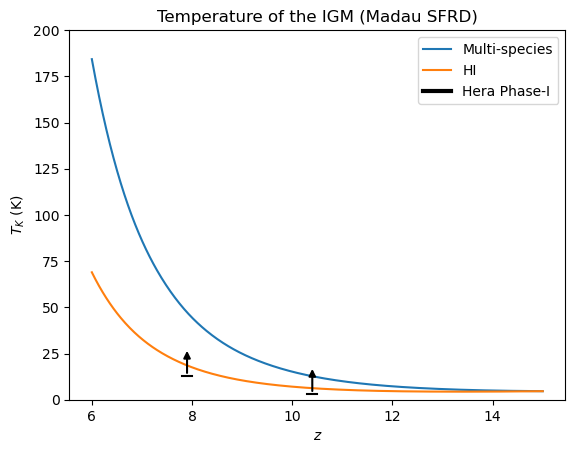

In [160]:
z_sol_grid_FullSigma = T_sol_FullSigma.t[::-1]
T_sol_vals_FullSigma = T_sol_FullSigma.y[0][::-1]

plt.plot(z_sol_grid_FullSigma, T_sol_vals_FullSigma, label = r'Multi-species')
plt.plot(z_sol_grid, T_sol_vals, label = r'HI')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_K$ (K)')
plt.title(r'Temperature of the IGM (Madau SFRD)')
plt.legend()

# --- Literature constraints ---

# Redshifts
z1 = 10.4
z2 = 7.9

# Temperature limits (from paper)
T1_min, T1_max = 3.2, 313.2      # at z = 10.4
T2_min, T2_max = 13, 4768        # at z = 7.9

# --- Vertical lines at the redshifts ---
#plt.axvline(z1, color='black', linestyle='--', alpha=0.7)
#plt.axvline(z2, color='black', linestyle='--', alpha=0.7)

# --- Plot vertical segments showing allowed temperature ranges ---
plt.plot(z1, T1_min, color='black', linewidth=3, label='Hera Phase-I')
plt.plot(z2, T2_min, color='black', linewidth=3)

# --- Optional: caps to make it look cleaner (like error bars) ---
plt.plot([z1-0.1, z1+0.1], [T1_min, T1_min], color='black')
plt.plot([z1-0.1, z1+0.1], [T1_max, T1_max], color='black')

plt.plot([z2-0.1, z2+0.1], [T2_min, T2_min], color='black')
plt.plot([z2-0.1, z2+0.1], [T2_max, T2_max], color='black')

offset = 15

plt.annotate(
    '', 
    xy=(z1, T1_min + offset),   # arrow head (above)
    xytext=(z1, T1_min),        # start at point
    arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5)
)

plt.annotate(
    '', 
    xy=(z2, T2_min + offset),
    xytext=(z2, T2_min),
    arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5)
)
plt.ylim(0, 200)
plt.legend()

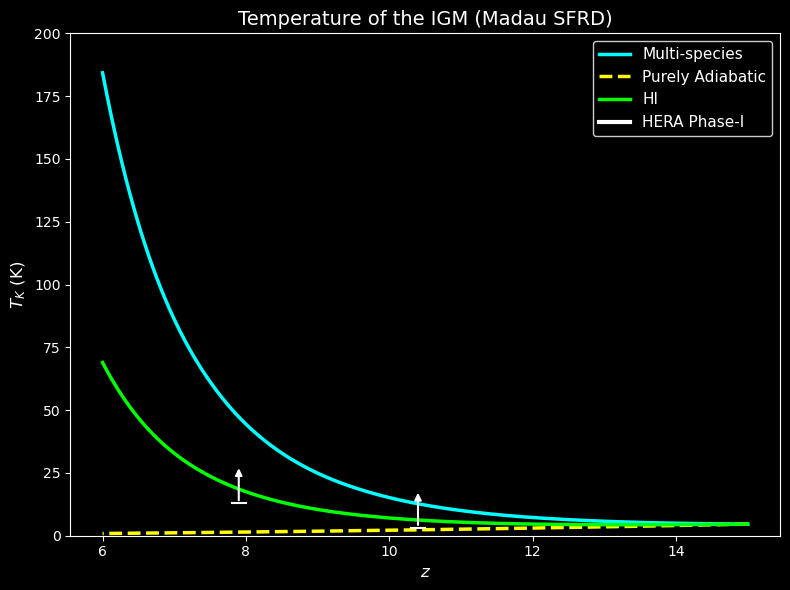

In [161]:
# Extract data
z_sol_grid_FullSigma = T_sol_FullSigma.t[::-1]
T_sol_vals_FullSigma = T_sol_FullSigma.y[0][::-1]

adiabatic_temp_vals = adiabatic_temperature(z_sol_grid_FullSigma[::-1], in_Temp(15))

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.plot(z_sol_grid_FullSigma, T_sol_vals_FullSigma,
        label=r'Multi-species', color='#00FFFF', lw=2.5)

ax.plot(z_sol_grid_FullSigma[::-1], adiabatic_temp_vals,
        label=r'Purely Adiabatic', color='#FFFF00', lw=2.5, ls='--')

ax.plot(z_sol_grid, T_sol_vals,
        label=r'HI', color='#00FF00', lw=2.5)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$T_K$ (K)', fontsize=12, color='white')
ax.set_title(r'Temperature of the IGM (Madau SFRD)', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Literature constraints ---
z1 = 10.4
z2 = 7.9

T1_min, T1_max = 3.2, 313.2
T2_min, T2_max = 13, 4768

constraint_color = 'white'

# Points
ax.plot(z1, T1_min, color=constraint_color, linewidth=3, label='HERA Phase-I')
ax.plot(z2, T2_min, color=constraint_color, linewidth=3)

# Caps
ax.plot([z1-0.1, z1+0.1], [T1_min, T1_min], color=constraint_color)
ax.plot([z1-0.1, z1+0.1], [T1_max, T1_max], color=constraint_color)

ax.plot([z2-0.1, z2+0.1], [T2_min, T2_min], color=constraint_color)
ax.plot([z2-0.1, z2+0.1], [T2_max, T2_max], color=constraint_color)

# Arrows
offset = 15

ax.annotate(
    '',
    xy=(z1, T1_min + offset),
    xytext=(z1, T1_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

ax.annotate(
    '',
    xy=(z2, T2_min + offset),
    xytext=(z2, T2_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

# --- Limits ---
ax.set_ylim(0, 200)

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

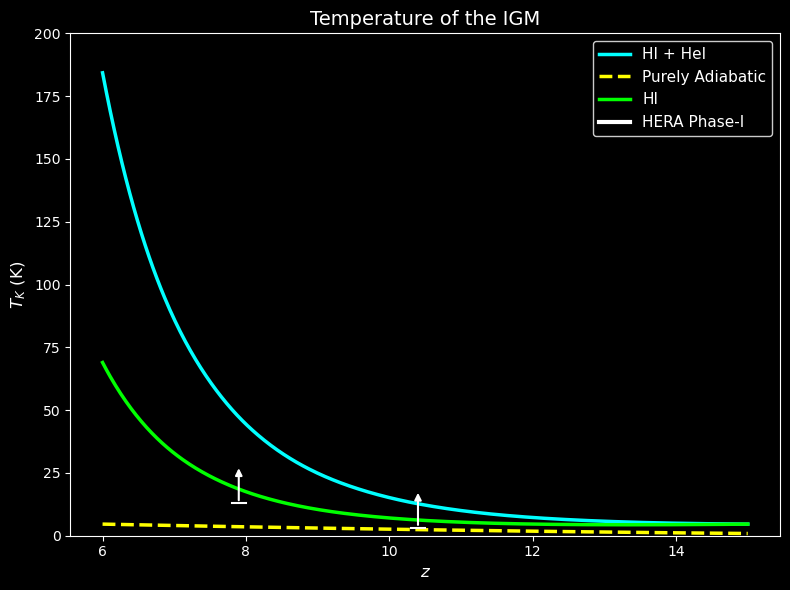

In [162]:
# Extract data
z_sol_grid_FullSigma = T_sol_FullSigma.t[::-1]
T_sol_vals_FullSigma = T_sol_FullSigma.y[0][::-1]

# Create figure
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Main curves ---
ax.plot(z_sol_grid_FullSigma, T_sol_vals_FullSigma,
        label=r'HI + HeI', color='#00FFFF', lw=2.5)

ax.plot(z_sol_grid_FullSigma, adiabatic_temp_vals,
        label=r'Purely Adiabatic', color='#FFFF00', lw=2.5, ls='--')

ax.plot(z_sol_grid, T_sol_vals,
        label=r'HI', color='#00FF00', lw=2.5)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$T_K$ (K)', fontsize=12, color='white')
ax.set_title(r'Temperature of the IGM', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Literature constraints ---
z1 = 10.4
z2 = 7.9

T1_min, T1_max = 3.2, 313.2
T2_min, T2_max = 13, 4768

# Use WHITE instead of black so it's visible
constraint_color = 'white'

# Vertical constraint points
ax.plot(z1, T1_min, color=constraint_color, linewidth=3, label='HERA Phase-I')
ax.plot(z2, T2_min, color=constraint_color, linewidth=3)

# Caps
ax.plot([z1-0.1, z1+0.1], [T1_min, T1_min], color=constraint_color)
ax.plot([z1-0.1, z1+0.1], [T1_max, T1_max], color=constraint_color)

ax.plot([z2-0.1, z2+0.1], [T2_min, T2_min], color=constraint_color)
ax.plot([z2-0.1, z2+0.1], [T2_max, T2_max], color=constraint_color)

# Arrows
offset = 15

ax.annotate(
    '',
    xy=(z1, T1_min + offset),
    xytext=(z1, T1_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

ax.annotate(
    '',
    xy=(z2, T2_min + offset),
    xytext=(z2, T2_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

# --- Limits ---
ax.set_ylim(0, 200)

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

# Reionized IGM Calculations

## Full $\lambda_\text{X}$ (Valid for All Energies)

### Fitting Function for Cosmological Reionization

In [163]:
from utils import Mad_data

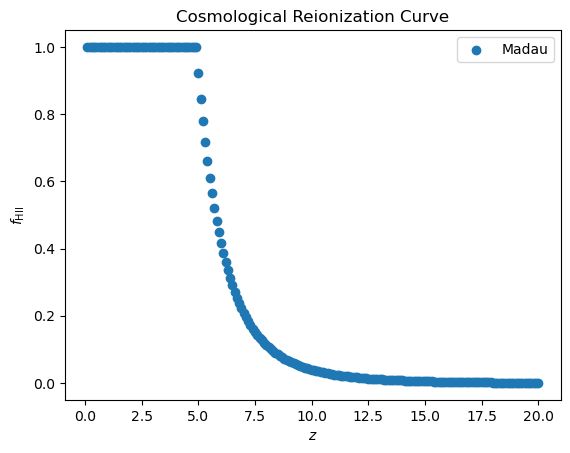

In [164]:
plt.scatter(Mad_data[0], Mad_data[1], label = r'Madau')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.title(r'Cosmological Reionization Curve')
plt.legend()

In [165]:
mask = Mad_data[1] >= 1

if np.any(mask):
    idx = np.argmax(mask)
else:
    idx = len(Mad_data[1]) - 1

In [166]:
f_reion_new = Mad_data[1][:idx+1]
z_reion_new = Mad_data[0][:idx+1]

In [167]:
from scipy.optimize import curve_fit

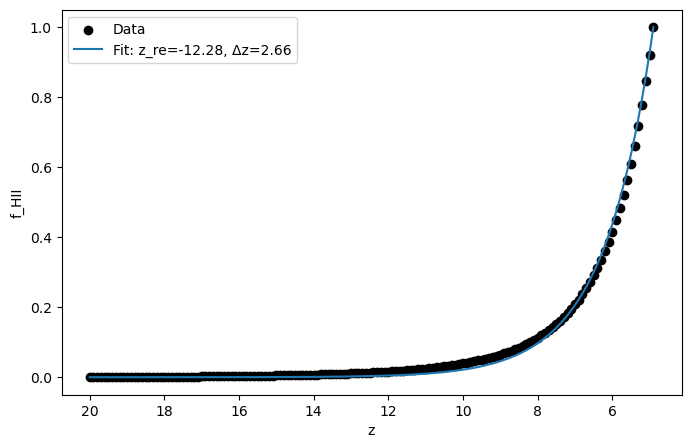

In [168]:
z = z_reion_new
f = f_reion_new

z0, zN = z[0], z[-1]

# tanh model with endpoint normalization
def tanh_model(z, z_re, delta_z):
    t = np.tanh((z - z_re) / delta_z)
    
    t0 = np.tanh((z0 - z_re) / delta_z)
    t1 = np.tanh((zN - z_re) / delta_z)
    
    return (t - t0) / (t1 - t0)

# initial guesses
z_re_guess = z[np.argmin(np.abs(f - 0.5))]
delta_z_guess = 1.0

p0 = [z_re_guess, delta_z_guess]

# fit
params, _ = curve_fit(tanh_model, z, f, p0=p0)

z_re_fit, delta_z_fit = params

# fitted curve
f_fit = tanh_model(z, z_re_fit, delta_z_fit)

# plot
plt.figure(figsize=(8,5))
plt.scatter(z, f, color='black', label='Data')
plt.plot(z, f_fit, label=f'Fit: z_re={z_re_fit:.2f}, Δz={delta_z_fit:.2f}')

plt.xlabel('z')
plt.ylabel('f_HII')
plt.legend()
plt.gca().invert_xaxis()
plt.show()

In [169]:
# store endpoints once
z0 = z_reion_new[0]   # highest z (fraction ~ 0)
zN = z_reion_new[-1]  # lowest z (fraction ~ 1)

def f_reion_model(z_input):
    z_input = np.asarray(z_input)  # handle scalars + arrays
    
    # compute tanh fit
    t = np.tanh((z_input - z_re_fit) / delta_z_fit)
    t0 = np.tanh((z0 - z_re_fit) / delta_z_fit)
    t1 = np.tanh((zN - z_re_fit) / delta_z_fit)
    
    f_fit = (t - t0) / (t1 - t0)
    
    # apply physical bounds
    f_out = np.where(
        z_input > z0, 0.0,            # higher z → neutral
        np.where(
            z_input < zN, 1.0,        # lower z → fully ionized
            f_fit                     # inside domain → fit
        )
    )
    
    return f_out

In [170]:
test_f_arr = np.zeros_like(z_range)

for i in range(len(z_range)):
    test_f_arr[i] = f_reion_model(z_range[i])

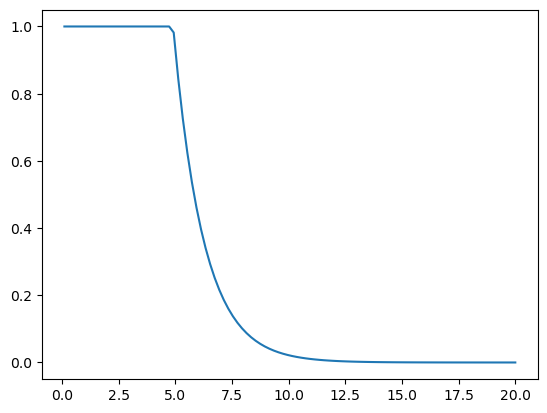

In [171]:
plt.plot(z_range, test_f_arr)

In [172]:
def Lambda_X_FullSigma(E, z):
    m_p_SM = m_p * 5.03 * 10 ** (-34)
    n_H0 = Om_b * rho_c / m_p_SM
    y = 0.083
    eff_sigma_Mpc = ((1 - f_reion_model(z)) * sigma_FullSigma(E, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI) + y * (1 - f_reion_model(z)) * sigma_FullSigma(E, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI) + y * f_reion_model(z) * sigma_FullSigma(E, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)) * (3.24 * 10 ** (-25)) ** 2
    X = 0.75
    return (1 + z) ** (-3) / (X * n_H0 * eff_sigma_Mpc)

In [173]:
Lambda_FullSigma_Vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    Lambda_FullSigma_Vals[i] = Lambda_X_FullSigma(1, Mad_data[0][i])

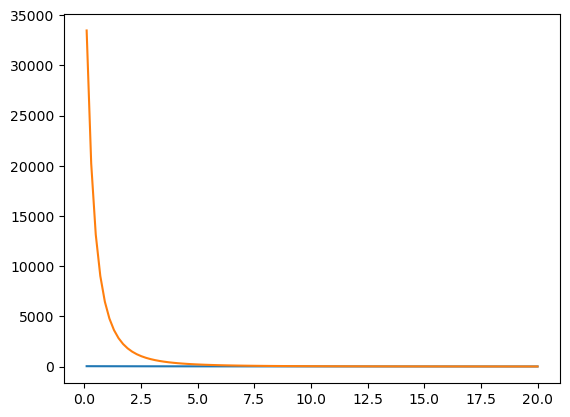

In [174]:
plt.plot(z_range, Lambda_FullSigma_Vals[::-1])
plt.plot(z_range, MFP_test_arr)

In [175]:
Lambda_FullSigma_valsE = np.zeros_like(E_range)
Lambda_neutralSigma_valsE = np.zeros_like(E_range)

for i in range(len(E_range)):
    Lambda_FullSigma_valsE[i] = Lambda_X_FullSigma(E_range[i], Mad_data[0][120])
    Lambda_neutralSigma_valsE[i] = MFP_X(E_range[i], Mad_data[0][120])

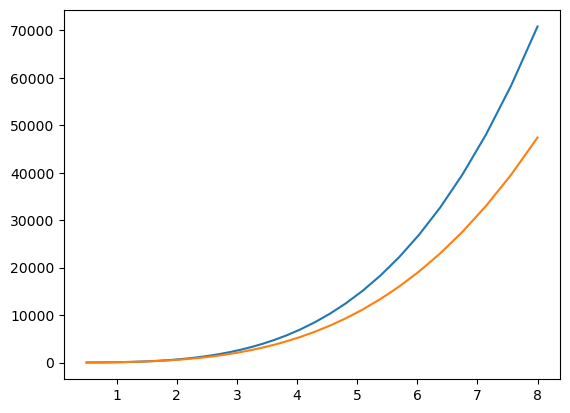

In [176]:
plt.plot(E_range, Lambda_FullSigma_valsE)
plt.plot(E_range, Lambda_neutralSigma_valsE)

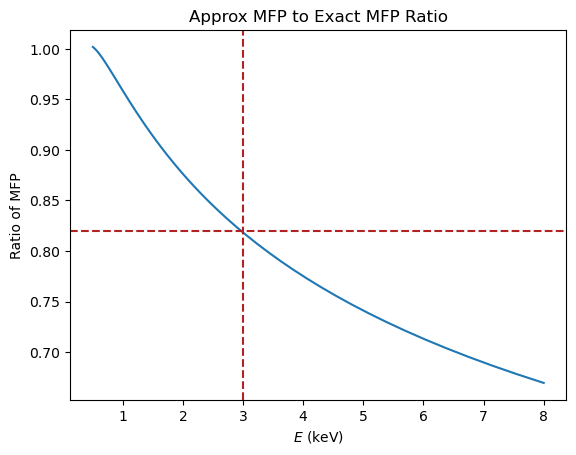

In [177]:
Lambda_vals_ratio = Lambda_neutralSigma_valsE / Lambda_FullSigma_valsE

plt.plot(E_range, Lambda_vals_ratio)
plt.axhline(0.82, ls = '--', color = r'firebrick')
plt.axvline(3, ls = '--', color = r'firebrick')
plt.ylabel(r'Ratio of MFP')
plt.xlabel(r'$E$ (keV)')

plt.title(r'Approx MFP to Exact MFP Ratio')

"""

# Folder where you want to save the figure
save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/XRay_Heating"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "MFP_Ratios.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [178]:
def Tau_X_integrand_FullSigma(E_prime, z_b, z_p): #Dummy variable of integration
    c_val = (3 * 10 ** 5) * 3.154 * 10 ** 7 #speed of light in km/yr
    E = E_prime * (1 + z_b) / (1 + z_p)
    return c_val / ((1 + z_b) * (H(z_b) * 3.086 * 10 ** (19)) * Lambda_X_FullSigma(E, z_b)) #H(z) in km/yr*Mpc

@jit(nopython=True)
def Tau_X_FullSigma(E_p, z_p, z, delta_z): #X-ray Optical Depth, proper coordinates at some emission redshift z_p and energy E_p, observed at z
    c_val = (3 * 10 ** 5) * 3.154 * 10 ** 7 #speed of light in km/yr
    integration_steps = int((z_p - z) / delta_z)
    z_arr = np.linspace(z, z_p, integration_steps)
    integrand_vals = np.zeros_like(z_arr)
    for i in range(len(z_arr)):
        integrand_vals[i] = Tau_X_integrand(E_p, z_arr[i], z_p)
    return np.trapz(integrand_vals, z_arr)

In [179]:
tau_FullSigma_vals = np.zeros_like(z_range)

z_obs_test = 8

for i in range(len(z_range)):
    if z_range[i] > z_obs_test:
        tau_FullSigma_vals[i] = Tau_X_FullSigma(1, z_range[i], z_obs_test, 0.0001)

Text(0.5, 1.0, 'Optical Depth')

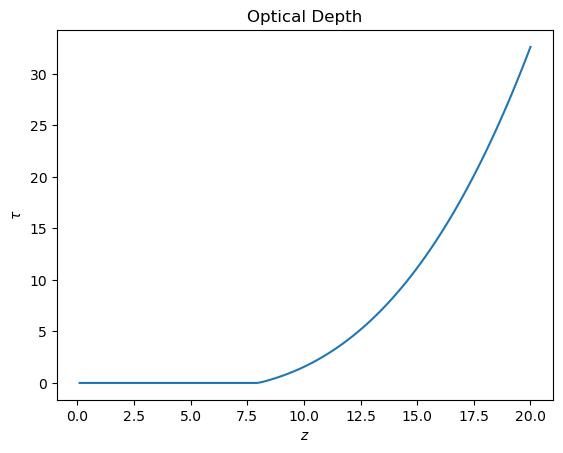

In [180]:
plt.plot(z_range, tau_FullSigma_vals)
plt.xlabel(r'$z$')
plt.ylabel(r'$\tau$')
plt.title(r'Optical Depth')

In [181]:
cX_vals = np.mean(mean_cx_scat) #In erg/s * yr/M
MpctoKm = 3.086 * 10 ** (19)
Yrtosec = 3.154 * 10 ** 7

def J_E_integrand_FullSigma_reion(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return Hopkin_SFRD(z_prime) * cX_vals * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * MpctoKm / (Yrtosec))
    ) * np.exp(-Tau_X_FullSigma(E_prime, z_prime, z_obs, 0.001))

#
#

def J_FullSigma_reion(E, z):

    gamma_index = 2
    c_kms = 3e5

    z_start = z
    z_end = z + 4
    n_steps = 1000

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)
    #

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_FullSigma_reion(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_FullSigma_reion(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [182]:
J_test_vals2_FullSigma_reion = np.zeros_like(E_range) #J_E spectrum
J_test_vals3_FullSigma_reion = np.zeros_like(E_range)
J_test_vals4_FullSigma_reion = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_vals2_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 8)
    J_test_vals3_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 10)
    J_test_vals4_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 12)

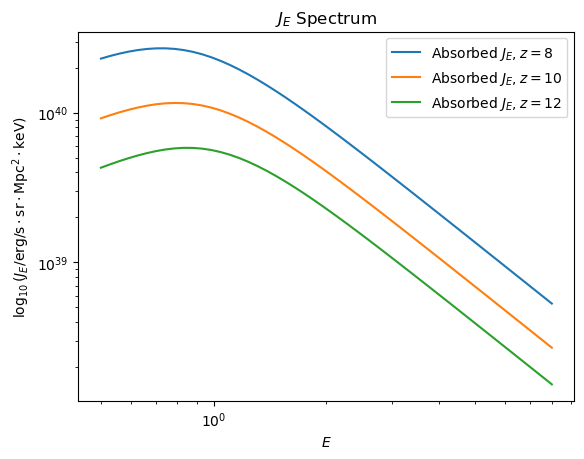

In [183]:
plt.loglog(E_range, J_test_vals2_FullSigma_reion, label = r'Absorbed $J_E, z=8$')
#
plt.loglog(E_range, J_test_vals3_FullSigma_reion, label = r'Absorbed $J_E, z=10$')
plt.loglog(E_range, J_test_vals4_FullSigma_reion, label = r'Absorbed $J_E, z=12$')
plt.xlabel(r'$E$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

In [184]:
cX_vals = np.mean(mean_cx_scat) #In erg/s * yr/M
MpctoKm = 3.086 * 10 ** (19)
Yrtosec = 3.154 * 10 ** 7

def J_E_integrand_FullSigma_reion(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return Hopkin_SFRD(z_prime) * cX_vals * (1 + z_prime) ** (-gamma_index) / (
        (1 + z_prime) * (H(z_prime) * MpctoKm / Yrtosec)
    ) * np.exp(-Tau_X_FullSigma(E_prime, z_prime, z_obs, 0.001))


def J_FullSigma_reion(E, z):

    gamma_index = 2
    c_kms = 3e5

    z_start = z
    z_end = z + 4

    # can probably be reduced from 1000
    n_steps = 300

    normalization = (
        (8 ** (1 - gamma_index)) / (1 - gamma_index)
        -
        (0.5 ** (1 - gamma_index)) / (1 - gamma_index)
    )

    # non-uniform grid concentrated near z_start
    u = np.linspace(0, 1, n_steps)

    z_grid = z_start + (z_end - z_start) * u**3

    integrand_vals = np.array([
        J_E_integrand_FullSigma_reion(E, z, zp)
        for zp in z_grid
    ])

    integral = np.trapezoid(integrand_vals, z_grid)

    y_val = (
        c_kms / (4 * np.pi)
        * (1 + z) ** 3
        * (E ** (-gamma_index) / normalization)
        * integral
        / (1 + z) ** (-gamma_index)
    )

    return y_val

In [185]:
J_test_vals2_FullSigma_reion = np.zeros_like(E_range) #J_E spectrum
J_test_vals3_FullSigma_reion = np.zeros_like(E_range)
J_test_vals4_FullSigma_reion = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_vals2_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 8)
    J_test_vals3_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 10)
    J_test_vals4_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 12)

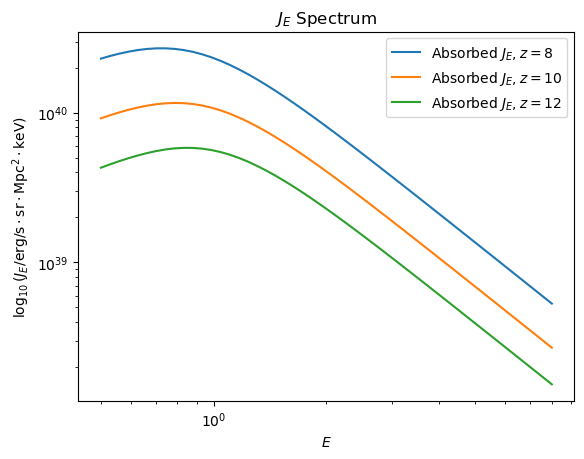

In [186]:
plt.loglog(E_range, J_test_vals2_FullSigma_reion, label = r'Absorbed $J_E, z=8$')
#
plt.loglog(E_range, J_test_vals3_FullSigma_reion, label = r'Absorbed $J_E, z=10$')
plt.loglog(E_range, J_test_vals4_FullSigma_reion, label = r'Absorbed $J_E, z=12$')
plt.xlabel(r'$E$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

In [187]:
print(J_FullSigma_reion(0.3, 8))
print(J_FullSigma_reion(0.5, 8))

1.402235631221917e+40
2.3056231178280936e+40


## Photo-Heating Rates (Full Neutral IGM)

In [188]:
#Note: Since J_E is smaller by about 5 times that in the Madau paper, I multiply an explicit factor of 5 here

def H_HI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (5 * J_FullSigma_reion(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 10 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HeI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (5 * J_FullSigma_reion(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HeI_KEV) * sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 10 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HeII_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (5 * J_FullSigma_reion(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HeI_KEV) * sigma_FullSigma(E_val, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 10 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [189]:
H_HI_vals_FullSigma_reion = np.zeros_like(z_grid)
H_HeI_vals_FullSigma_reion = np.zeros_like(z_grid)
H_HeII_vals_FullSigma_reion = np.zeros_like(z_grid)

for i in range(len(z_grid)):
    H_HI_vals_FullSigma_reion[i] = H_HI_FullSigma_reion(z_grid[i])
    H_HeI_vals_FullSigma_reion[i] = H_HeI_FullSigma_reion(z_grid[i])
    H_HeII_vals_FullSigma_reion[i] = H_HeII_FullSigma_reion(z_grid[i])

In [198]:
H_reion_vals_Data = np.column_stack((H_HI_vals_FullSigma_reion, H_HeI_vals_FullSigma_reion, H_HeII_vals_FullSigma_reion))

np.savetxt("../Data/H_reion_ValsData.csv", H_reion_vals_Data, delimiter = ",", header = "H_HI, H_HeI, H_HeII")

In [191]:
H_HI_vals_FullSigma_reion, H_HeI_vals_FullSigma_reion, H_HeII_vals_FullSigma_reion = np.genfromtxt("../Data/H_reion_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

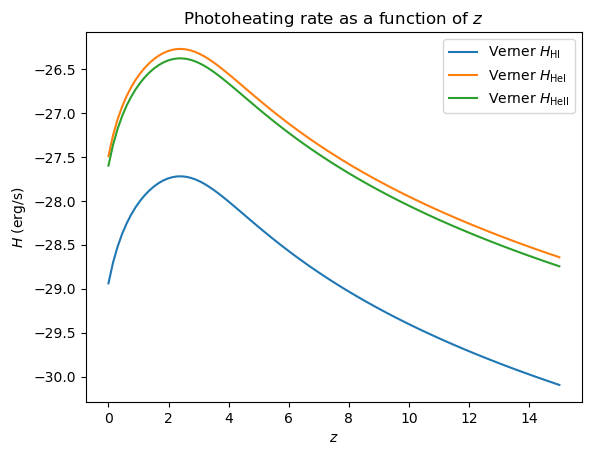

In [192]:
#plt.plot(z_grid, np.log10(H_HI_vals), label = r'Approx. $H_\text{HI} (Q=0)$')
#plt.plot(z_grid, np.log10(H_HI_vals_FullSigma), label = r'Verner $H_\text{HI} (Q=0)$')
#plt.plot(z_grid, np.log10(H_HeI_vals_FullSigma), label = r'Verner $H_\text{HeI} (Q=0)$')
plt.plot(z_grid, np.log10(H_HI_vals_FullSigma_reion), label = r'Verner $H_\text{HI}$')
plt.plot(z_grid, np.log10(H_HeI_vals_FullSigma_reion), label = r'Verner $H_\text{HeI}$')
plt.plot(z_grid, np.log10(H_HeII_vals_FullSigma_reion), label = r'Verner $H_\text{HeII}$')
plt.ylabel(r'$H$ (erg/s)')
plt.xlabel(r'$z$')
plt.title(r'Photoheating rate as a function of $z$')
plt.legend()

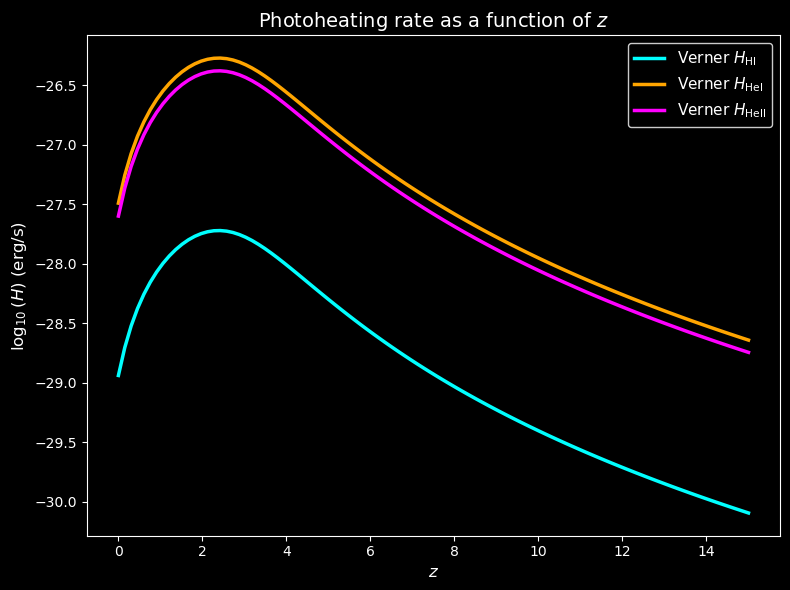

In [193]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.plot(z_grid, np.log10(H_HI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HI}$',
        color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeI}$',
        color='#FFA500', lw=2.5)   # orange

ax.plot(z_grid, np.log10(H_HeII_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeII}$',
        color='#FF00FF', lw=2.5)   # magenta

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(H)$ (erg/s)', fontsize=12, color='white')
ax.set_title(r'Photoheating rate as a function of $z$', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

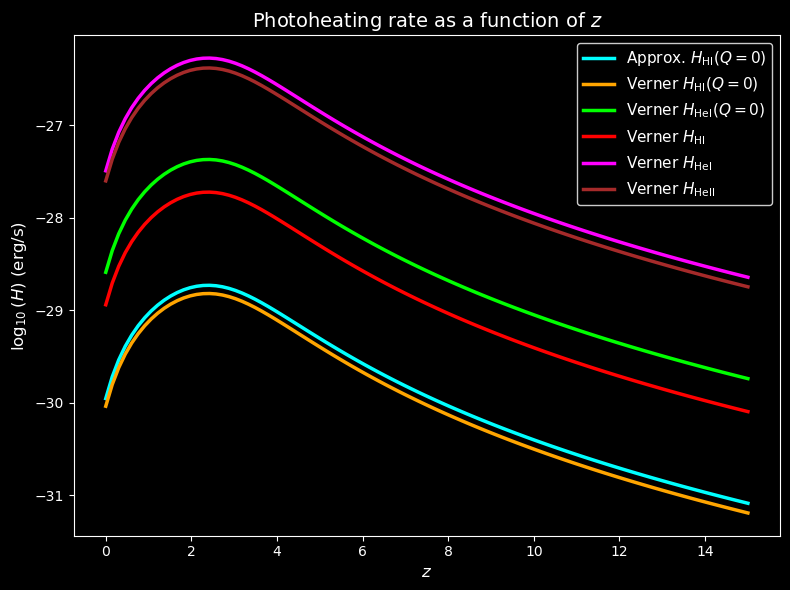

In [194]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves (carefully chosen colors for contrast) ---
ax.plot(z_grid, np.log10(H_HI_vals),
        label=r'Approx. $H_\text{HI} (Q=0)$',
        color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_grid, np.log10(H_HI_vals_FullSigma),
        label=r'Verner $H_\text{HI} (Q=0)$',
        color='#FFA500', lw=2.5)   # orange

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma),
        label=r'Verner $H_\text{HeI} (Q=0)$',
        color='#00FF00', lw=2.5)   # green

ax.plot(z_grid, np.log10(H_HI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HI}$',
        color='#FF0000', lw=2.5)   # red

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeI}$',
        color='#FF00FF', lw=2.5)   # magenta

ax.plot(z_grid, np.log10(H_HeII_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeII}$',
        color='#A52A2A', lw=2.5)   # brown-ish (distinct from magenta)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(H)$ (erg/s)', fontsize=12, color='white')
ax.set_title(r'Photoheating rate as a function of $z$', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

### Secondary Ionization Correction Calculations

In [195]:
ergTokeV = 6.242 * 10 ** 8

#Note: Since J_E is smaller by about 5 times that in the Madau paper, I multiply an explicit factor of 5 here

def PhotoIonRate_HI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (5 * J_FullSigma_reion(E_val, z_val) * ergTokeV / (3.086 * 10 ** 24) ** 2) / E_val * sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def PhotoIonRate_HeI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (5 * J_FullSigma_reion(E_val, z_val) * ergTokeV / (3.086 * 10 ** 24) ** 2) / E_val * sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def PhotoIonRate_HeII_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (5 * J_FullSigma_reion(E_val, z_val) * ergTokeV / (3.086 * 10 ** 24) ** 2) / E_val * sigma_FullSigma(E_val, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [199]:
PhotoIonRate_HI_vals_FullSigma_reion = np.zeros_like(z_grid)
PhotoIonRate_HeI_vals_FullSigma_reion = np.zeros_like(z_grid)
PhotoIonRate_HeII_vals_FullSigma_reion = np.zeros_like(z_grid)

for i in range(len(z_grid)):
    PhotoIonRate_HI_vals_FullSigma_reion[i] = PhotoIonRate_HI_FullSigma_reion(z_grid[i])
    PhotoIonRate_HeI_vals_FullSigma_reion[i] = PhotoIonRate_HeI_FullSigma_reion(z_grid[i])
    PhotoIonRate_HeII_vals_FullSigma_reion[i] = PhotoIonRate_HeII_FullSigma_reion(z_grid[i])

In [200]:
PhotoIonRate_reion_vals_Data = np.column_stack((PhotoIonRate_HI_vals_FullSigma_reion, PhotoIonRate_HeI_vals_FullSigma_reion, PhotoIonRate_HeII_vals_FullSigma_reion))

np.savetxt("../Data/PhotoIonRate_reion_ValsData.csv", PhotoIonRate_reion_vals_Data, delimiter = ",", header = "PhotoIonRate_HI, PhotoIonRate_HeI, PhotoIonRate_HeII")

In [201]:
PhotoIonRate_HI_vals_FullSigma_reion, PhotoIonRate_HeI_vals_FullSigma_reion, PhotoIonRate_HeII_vals_FullSigma_reion = np.genfromtxt("../Data/PhotoIonRate_reion_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

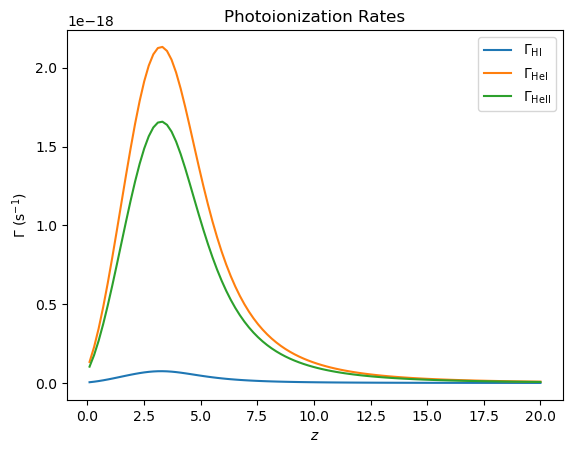

In [202]:
plt.plot(z_range, PhotoIonRate_HI_vals_FullSigma_reion, label = r'$\Gamma_\text{HI}$')
plt.plot(z_range, PhotoIonRate_HeI_vals_FullSigma_reion, label = r'$\Gamma_\text{HeI}$')
plt.plot(z_range, PhotoIonRate_HeII_vals_FullSigma_reion, label = r'$\Gamma_\text{HeII}$')

plt.xlabel(r'$z$')
plt.ylabel(r'$\Gamma$ (s$^{-1}$)')
plt.title(r'Photoionization Rates')

plt.legend()

In [203]:
Gamma_HI_interp = interp1d(z_grid, PhotoIonRate_HI_vals_FullSigma_reion, fill_value="extrapolate")
Gamma_HeI_interp = interp1d(z_grid, PhotoIonRate_HeI_vals_FullSigma_reion, fill_value="extrapolate")
Gamma_HeII_interp = interp1d(z_grid, PhotoIonRate_HeII_vals_FullSigma_reion, fill_value="extrapolate")

H_HI_interp = interp1d(z_grid, H_HI_vals_FullSigma_reion, fill_value="extrapolate")
H_HeI_interp = interp1d(z_grid, H_HeI_vals_FullSigma_reion, fill_value="extrapolate")
H_HeII_interp = interp1d(z_grid, H_HeII_vals_FullSigma_reion, fill_value="extrapolate")

In [204]:
m_p = 1.67 * 10 ** (-24) #in g

m_p_SM = m_p * 5.03 * 10 ** (-34)  #in Solar Masses

kmToMpc = 3.24 * 10 ** (-20)

def Hubble(z): #in km/s/Mpc
    return 67 * np.sqrt(Om_m * (1 + z)**3 + Om_lambda) * kmToMpc

def number_densities(z): #/Mpc^3
    rho_b = Om_b * rho_c * (1 + z)**3

    n_H = 0.75 * rho_b / m_p_SM
    n_He = 0.25 * rho_b / (4 * m_p_SM)

    return n_H, n_He

def full_mu(frac_H, frac_He, x_HI, x_HeI, x_HeII):
    x_HII = 1 - x_HI
    x_HeIII = 1 - (x_HeI + x_HeII)
    return 1 / (frac_H + frac_He / 4 + x_HII * frac_H + frac_He / 4 * (x_HeII + 2 * x_HeIII))

def full_dmu_dz(frac_H, frac_He, mu, dxHI_dz, dxHeI_dz, dxHeII_dz):
    return mu ** 2 * (frac_H * dxHI_dz + (frac_He) / 4 * (dxHeI_dz + dxHeII_dz))

CmtoMpc = 3.24 * 10 ** (-25)

def alpha_HII(T): #Mpc^3/s
    return 6.30 * 10 ** (-11) * T ** (-1 / 2) * (T / 10 ** 3) ** (-0.2) / (1 + (T / 10 ** 6) ** (0.7)) * (CmtoMpc) ** 3

def alpha_HeII(T): #Mpc^3/s
    return 1.5 * 10 ** (-10) * T ** (-0.6353) * (CmtoMpc) ** 3

def alpha_HeII_D(T): #Mpc^3/s
    return 1.9 * 10 ** (-3) * T ** (-1.5) * np.e ** (-4.7 * 10 ** 5 / T) * (1 + 0.3 * np.e ** (-9.4 * 10 ** 4 / T))

def alpha_HeIII(T): #Mpc^3/s
    return (3.36 * 10 ** (-10) * T ** (-1 / 2) * (T / 10 ** 3) ** (-0.2) / (1 + (T / 10 ** 6) ** (0.7)) + alpha_HeII_D(T)) * (CmtoMpc) ** 3

def f_ion_HI(x_e):
    return 0.3908 * (1 - x_e ** 0.4092) ** 1.7592

def f_ion_HeI(x_e):
    return 0.0554 * (1 - x_e ** 0.4614) ** 1.666

def f_heat(x_e):
    return 1 - (1 - x_e ** 0.2663) ** 1.3163

def frac_e(frac_H, frac_He, x_HI, x_HeI, x_HeII):
    x_HeIII = 1 - x_HeI - x_HeII
    return (1 - x_HI) + frac_He / (4 * frac_H) * (x_HeII + 2 * x_HeIII)

In [205]:
def FullHeating_RHS(z, Y):
    T_K, x_HI, x_HeI, x_HeII = Y
    x_HeIII = 1 - x_HeI - x_HeII
    mu_val = full_mu(0.75, 0.25, x_HI, x_HeI, x_HeII)
    n_H_val, n_He_val = number_densities(z)

    rho_b = Om_b * rho_c * (1 + z) ** 3

    n_e_val = (1 - x_HI) * n_H_val + n_He_val * (2 - x_HeII - 2 * x_HeI)

    x_e_val = frac_e(0.75, 0.25, x_HI, x_HeI, x_HeII)

    f_ion_HI_val = f_ion_HI(x_e_val)
    f_ion_HeI_val = f_ion_HeI(x_e_val)
    f_heat_val = f_heat(x_e_val)

    H_HI_corrected = f_heat_val * H_HI_interp(z)
    H_HeI_corrected = f_heat_val * H_HeI_interp(z)
    H_HeII_corrected = f_heat_val * H_HeII_interp(z)

    #corrected photoionization rates
    eVToerg = 1.6 * 10 ** (-12)
    I_HI = 13.598 * eVToerg #erg
    I_HeI = 24.587 * eVToerg #erg
    gamma_new_HI = Gamma_HI_interp(z) + f_ion_HI_val / I_HI * ((x_HI * n_H_val * H_HI_interp(z) + (x_HeI * H_HeI_interp(z) + x_HeII * H_HeII_interp(z)) * n_He_val) / (x_HI * n_H_val))
    gamma_new_HeI = Gamma_HeI_interp(z) + f_ion_HeI_val / I_HeI * ((x_HI * n_H_val * H_HI_interp(z) + (x_HeI * H_HeI_interp(z) + x_HeII * H_HeII_interp(z)) * n_He_val) / (x_HeI * n_He_val))
    
    dxHI_dz = x_HI * gamma_new_HI / (Hubble(z) * (1 + z)) - 1 / (Hubble(z) * (1 + z)) * n_e_val * (1 - x_HI) * alpha_HII(T_K)
    dxHeI_dz = x_HeI * gamma_new_HeI / (Hubble(z) * (1 + z)) - 1 / (Hubble(z) * (1 + z)) * n_e_val * x_HeII * alpha_HeII(T_K)
    dxHeII_dz = x_HeII * Gamma_HeII_interp(z) / (Hubble(z) * (1 + z)) - 1 / (Hubble(z) * (1 + z)) * n_e_val * x_HeIII * alpha_HeIII(T_K) - dxHeI_dz
    
    dmu_dz_val = full_dmu_dz(0.75, 0.25, mu_val, dxHI_dz, dxHeI_dz, dxHeII_dz)

    tot_photoheating = x_HI * n_H_val * H_HI_corrected + (x_HeI * H_HeI_corrected + x_HeII * H_HeII_corrected) * n_He_val

    dT_K_dz = 2 * T_K / (1 + z) + T_K / mu_val * dmu_dz_val - 2 * mu_val * m_p_SM / (3 * 1.38 * 10 ** (-16) * rho_b) * tot_photoheating / (Hubble(z) * (1 + z))

    return [dT_K_dz, dxHI_dz, dxHeI_dz, dxHeII_dz]

In [206]:
Y0 = [4.6, 1 - 10 ** (-3.7), 1 - 10 ** (-6), 10 ** (-6)]

sol_fullTemp = solve_ivp(
    FullHeating_RHS,
    t_span=(15, 0),
    y0=Y0,
    dense_output=True
)

z_fullheating = np.linspace(15, 0, 500)
T_K_FH, x_HI_FH, x_HeI_FH, x_HeII_FH = sol_fullTemp.sol(z_fullheating)

In [207]:
rho_b = Om_b * rho_c * (1 + 15)**3
print(rho_b)

25051135999999.992


(0.0, 300.0)

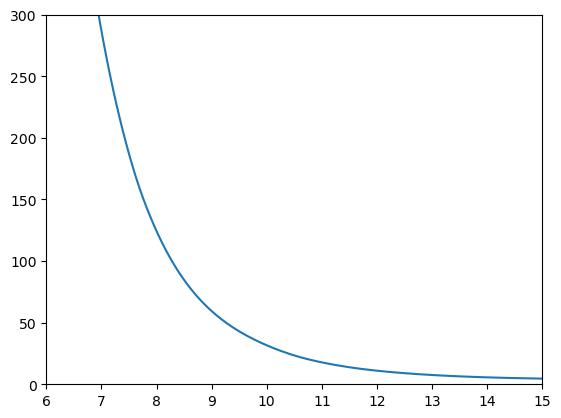

In [208]:
plt.plot(z_fullheating, T_K_FH)
plt.xlim(6, 15)
plt.ylim(0, 300)

(6.0, 15.0)

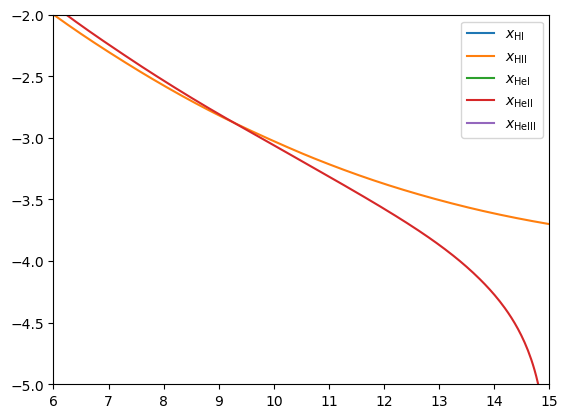

In [209]:
plt.plot(z_fullheating, np.log10(x_HI_FH), label = r'$x_\text{HI}$')
plt.plot(z_fullheating, np.log10(1 - x_HI_FH), label = r'$x_\text{HII}$')
plt.plot(z_fullheating, np.log10(x_HeI_FH), label = r'$x_\text{HeI}$')
plt.plot(z_fullheating, np.log10(x_HeII_FH), label = r'$x_\text{HeII}$')
plt.plot(z_fullheating, np.log10(1 - x_HeI_FH - x_HeII_FH), label = r'$x_\text{HeIII}$')
plt.legend()
plt.ylim(-5, -2)
plt.xlim(6,15)

In [210]:
x_HII_FH_test = (1 - x_HI_FH) * 10 ** (0.3)
x_HI_FH_test = 1 - x_HII_FH_test
x_e_FH_test = frac_e(0.75, 0.25, x_HI_FH_test, x_HeI_FH, x_HeII_FH)

(-5.0, -2.0)

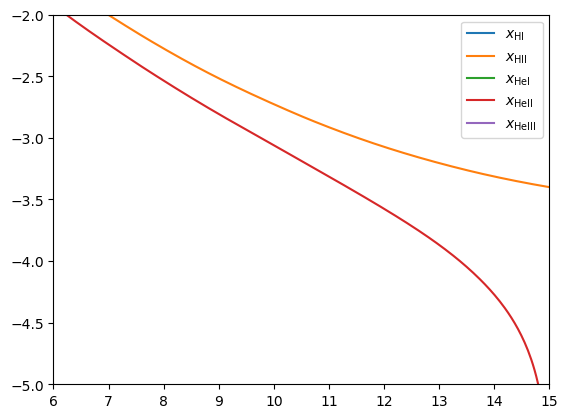

In [211]:
plt.plot(z_fullheating, np.log10(x_HI_FH_test), label = r'$x_\text{HI}$')
plt.plot(z_fullheating, np.log10(x_HII_FH_test), label = r'$x_\text{HII}$')
plt.plot(z_fullheating, np.log10(x_HeI_FH), label = r'$x_\text{HeI}$')
plt.plot(z_fullheating, np.log10(x_HeII_FH), label = r'$x_\text{HeII}$')
plt.plot(z_fullheating, np.log10(1 - x_HeI_FH - x_HeII_FH), label = r'$x_\text{HeIII}$')
plt.legend()
plt.xlim(6,15)
plt.ylim(-5, -2)

In [212]:
x_HI_interp_test = interp1d(z_fullheating, x_HI_FH_test, fill_value="extrapolate")
x_HII_interp_test = interp1d(z_fullheating, x_HII_FH_test, fill_value="extrapolate")

x_HeI_interp_test = interp1d(z_fullheating, x_HeI_FH, fill_value="extrapolate")
x_HeII_interp_test = interp1d(z_fullheating, x_HeII_FH, fill_value="extrapolate")

x_e_interp_test = interp1d(z_fullheating, x_e_FH_test, fill_value="extrapolate")

dxHI_dz_interp = interp1d(z_fullheating, np.gradient(x_HI_FH_test, z_fullheating), fill_value="extrapolate")
dxHeI_dz_interp = interp1d(z_fullheating, np.gradient(x_HeI_FH, z_fullheating), fill_value="extrapolate")
dxHeII_dz_interp = interp1d(z_fullheating, np.gradient(x_HeII_FH, z_fullheating), fill_value="extrapolate")

In [213]:
def Test_RHS(z, Y):

    T = Y[0]

    x_HI = float(x_HI_interp_test(z))
    x_HeI = float(x_HeI_interp_test(z))
    x_HeII = float(x_HeII_interp_test(z))

    x_e = float(x_e_interp_test(z))

    mu = full_mu(0.75, 0.25, x_HI, x_HeI, x_HeII)

    n_H_val, n_He_val = number_densities(z)

    rho_b = Om_b * rho_c * (1 + z)**3

    f_heat_val = f_heat(x_e)

    H_HI_corrected = f_heat_val * H_HI_interp(z)
    H_HeI_corrected = f_heat_val * H_HeI_interp(z)
    H_HeII_corrected = f_heat_val * H_HeII_interp(z)

    tot_photoheating = (
        x_HI * n_H_val * H_HI_corrected
        +
        (x_HeI * H_HeI_corrected
         + x_HeII * H_HeII_corrected)
        * n_He_val
    )

    dxHI_dz = float(dxHI_dz_interp(z))
    dxHeI_dz = float(dxHeI_dz_interp(z))
    dxHeII_dz = float(dxHeII_dz_interp(z))
    
    dmu_dz = full_dmu_dz(
        0.75,
        0.25,
        mu,
        dxHI_dz,
        dxHeI_dz,
        dxHeII_dz
    )

    dT_dz = (
        2 * T / (1 + z) + T/mu * dmu_dz
        -
        2 * mu * m_p_SM
        /
        (3 * 1.38e-16 * rho_b)
        *
        tot_photoheating
        /
        (Hubble(z) * (1 + z))
    )

    return [dT_dz]

In [214]:
sol_test = solve_ivp(
    Test_RHS,
    t_span=(15, 0),
    y0=[4.6],
    dense_output=True
)

T_test = sol_test.sol(z_fullheating)[0]

/tmp/ipykernel_6794/4089700116.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1000)


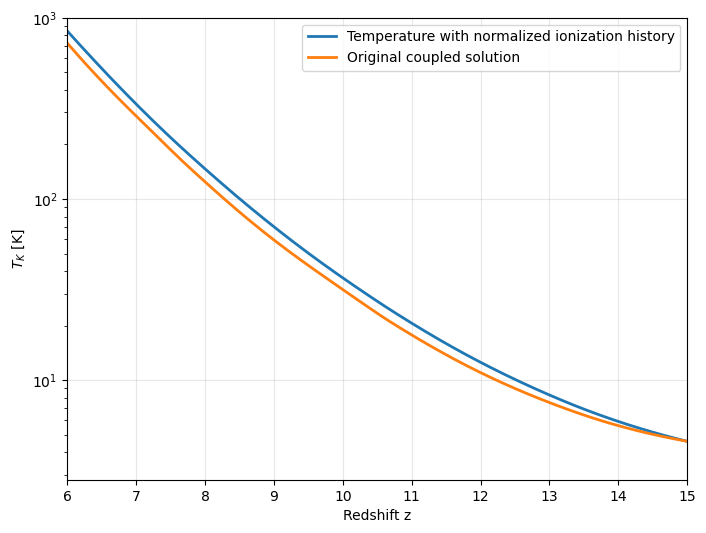

In [216]:
plt.figure(figsize=(8,6))

plt.plot(
    z_fullheating,
    T_test,
    lw=2,
    label="Temperature with normalized ionization history"
)

plt.plot(
    z_fullheating,
    T_K_FH,
    lw=2,
    label="Original coupled solution"
)

plt.xlabel("Redshift z")
plt.ylabel(r"$T_K$ [K]")

plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.xlim(6, 15)
plt.ylim(0, 1000)

plt.show()